In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'E:\Rnw\algorithms\Superviced learning\pr4\Message_Intelligence_Dataset_5200 - Message_Intelligence_Dataset_5200.csv.csv')

In [3]:
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

In [5]:
df.describe()

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5094.000000,5087.000000,5038.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.836317,296.671909,8.301906,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.697943,191.748754,5.586503,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.100000,148.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.600000,410.500000,10.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


In [6]:
df.columns

Index(['message_id', 'message_text', 'message_length', 'word_count',
       'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score',
       'legit_keyword_score', 'sender_activity_score',
       'sender_account_age_days', 'messages_sent_last_24h', 'timestamp',
       'hour_of_day', 'day_of_week', 'spam_label'],
      dtype='object')

In [7]:
print(df.isnull().sum())

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64


In [8]:
df = df.dropna()

In [9]:
X = df.drop(columns=['spam_label'])

In [10]:
y = df['spam_label']

In [11]:
X = df.drop(columns=['spam_label', 'message_id', 'message_text', 'timestamp'])

In [12]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['spam_label', 'message_id', 'message_text', 'timestamp'])
y = df['spam_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (3865, 12)
Testing Set: (967, 12)


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       1.00      1.00      1.00       180

    accuracy                           1.00       967
   macro avg       1.00      1.00      1.00       967
weighted avg       1.00      1.00      1.00       967



In [15]:
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    print(f"K={k}, Accuracy={acc:.4f}")

K=1, Accuracy=1.0000
K=2, Accuracy=1.0000
K=3, Accuracy=1.0000
K=4, Accuracy=1.0000
K=5, Accuracy=1.0000
K=6, Accuracy=1.0000
K=7, Accuracy=1.0000
K=8, Accuracy=1.0000
K=9, Accuracy=1.0000
K=10, Accuracy=1.0000
K=11, Accuracy=1.0000
K=12, Accuracy=1.0000
K=13, Accuracy=1.0000
K=14, Accuracy=0.9990
K=15, Accuracy=0.9990
K=16, Accuracy=0.9990
K=17, Accuracy=0.9990
K=18, Accuracy=0.9990
K=19, Accuracy=0.9990
K=20, Accuracy=0.9990


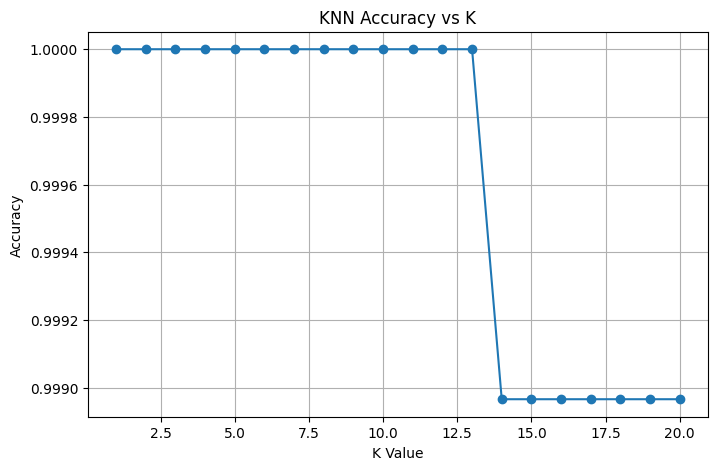

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.grid(True)
plt.show()

In [17]:
metrics = ['euclidean', 'manhattan', 'minkowski']

for metric in metrics:
    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    print(f"\nMetric: {metric}")
    print("Accuracy:", accuracy_score(y_test, y_pred))


Metric: euclidean
Accuracy: 1.0

Metric: manhattan
Accuracy: 1.0

Metric: minkowski
Accuracy: 1.0


In [18]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

misclassified = results[
    results['Actual'] != results['Predicted']
]

print("Number of Misclassified Messages:",
      len(misclassified))

misclassified.head()

Number of Misclassified Messages: 0


,Actual,Predicted


In [19]:
mis_idx = misclassified.index

df.loc[mis_idx, [
    'message_text',
    'spam_label'
]]

,message_text,spam_label


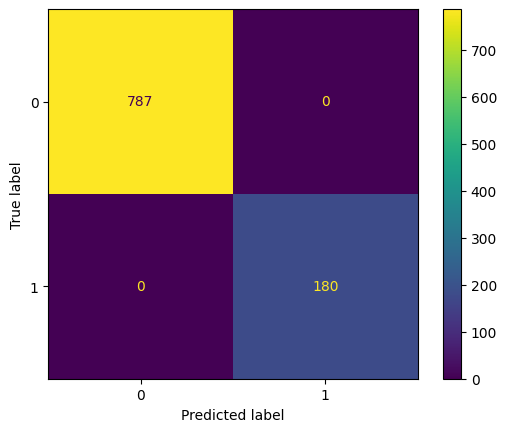

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()